# Previsão do valor de veículos com base na Tabela FIPE

## 1. Identificação e descrição do problema

| | |
|---|---|
| **Título** | Previsão do valor de veículos com base no histórico da Tabela FIPE (2001–2022) |
| **Integrantes** | Danillo Matos Garcez · Luciano Davi Martins de Santana Silva · Nicolas de Carvalho Lessa |
| **Fonte dos dados** | [Tabela Fipe — Kaggle (`franckepeixoto/tabela-fipe`)](https://www.kaggle.com/datasets/franckepeixoto/tabela-fipe) |
| **Atributo-alvo** | `valor` — preço médio de mercado do veículo, em reais (R$) |
| **Atributos preditivos** | `marca`, `modelo`, `anoModelo`, `mesReferencia`, `anoReferencia` — e atributos derivados deles (como a idade do veículo na data de referência), criados no pré-processamento |
| **Tipo da tarefa** | **Regressão** |

**Objetivo.** A Tabela FIPE é a principal referência de preços médios de veículos no Brasil, publicada
mensalmente e usada em negociações, seguros e financiamentos. Este trabalho constrói um modelo de
**regressão** capaz de estimar o valor FIPE de um veículo a partir de suas características (marca,
modelo, ano do modelo) e da data de referência (mês/ano da publicação). Com isso, é possível estimar
quanto um determinado carro valia — ou valeria — em um mês/ano dentro do período coberto pelos dados,
e analisar como os preços evoluem com a idade do veículo e com o tempo.

**Por que regressão?** O atributo-alvo (`valor`) é um número **contínuo** em reais, e não uma
categoria. O interesse é prever a magnitude do preço, portanto a tarefa é de regressão; classificação
só seria adequada se o alvo fosse discreto (ex.: faixas de preço).


## 2. Configuração do ambiente e obtenção dos dados

O notebook foi preparado para executar no **Google Colab** sem nenhum arquivo local: os dados são
baixados diretamente do Kaggle (fonte pública) por meio da biblioteca `kagglehub`, que não exige
credenciais para datasets públicos. As demais bibliotecas (pandas, NumPy, Matplotlib, scikit-learn)
já fazem parte do ambiente padrão do Colab.


In [1]:
# No Google Colab, apenas o kagglehub precisa ser instalado.
%pip install -q kagglehub


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paleta e estilo únicos para todos os gráficos do notebook
AZUL        = "#2a78d6"   # cor principal (série única / magnitude)
TINTA       = "#0b0b0b"   # texto principal
TINTA_SEC   = "#52514e"   # rótulos de eixo
CINZA_EIXO  = "#898781"
CINZA_GRADE = "#e1e0d9"
SUPERFICIE  = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor":   SUPERFICIE,
    "axes.edgecolor":   "#c3c2b7",
    "axes.grid": True,
    "grid.color": CINZA_GRADE,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": TINTA,
    "axes.labelcolor": TINTA_SEC,
    "axes.titlecolor": TINTA,
    "xtick.color": CINZA_EIXO,
    "ytick.color": CINZA_EIXO,
    "font.size": 11,
})

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


### 2.1 Download do dataset

O `kagglehub` baixa a versão mais recente do dataset e a mantém em cache local, portanto reexecutar a
célula não repete o download.


In [3]:
import kagglehub

caminho = kagglehub.dataset_download("franckepeixoto/tabela-fipe")
df = pd.read_csv(f"{caminho}/tabela-fipe-historico-precos.csv")

print(f"Registros: {df.shape[0]:,}".replace(",", "."))
print(f"Atributos: {df.shape[1]}")


Registros: 466.020
Atributos: 8


## 3. Compreensão dos dados

Nesta seção examinamos a estrutura do conjunto de dados: o que cada coluna significa, os tipos das
variáveis, valores ausentes, duplicações, inconsistências e a distribuição do atributo-alvo.

### 3.1 Estrutura geral


In [4]:
df.head(10)

,Unnamed: 0,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
0,0,038003-2,Acura,Integra GS 1.8,1992,11,2016,"13,041.00"
1,1,038001-6,Acura,NSX 3.0,1995,3,2013,"52,339.00"
2,2,038003-2,Acura,Integra GS 1.8,1992,3,2018,"12,423.00"
3,3,038002-4,Acura,Legend 3.2/3.5,1998,5,2016,"31,067.00"
4,4,038002-4,Acura,Legend 3.2/3.5,1998,2,2019,"26,381.00"
5,5,038002-4,Acura,Legend 3.2/3.5,1998,9,2015,"29,124.00"
6,6,038001-6,Acura,NSX 3.0,1995,10,2018,"43,081.00"
7,7,038003-2,Acura,Integra GS 1.8,1992,10,2019,"11,433.00"
8,8,038002-4,Acura,Legend 3.2/3.5,1998,5,2017,"29,258.00"
9,9,038001-6,Acura,NSX 3.0,1995,10,2013,"51,758.00"


Cada linha do dataset é **um preço de referência**: o valor médio de mercado de um veículo
(identificado por `codigoFipe` + `anoModelo`) publicado pela FIPE em um determinado mês/ano de
referência. O mesmo carro aparece, portanto, em várias linhas — uma para cada mês em que foi avaliado.

**Dicionário de dados:**

| Coluna | Significado |
|---|---|
| `Unnamed: 0` | Índice sequencial residual da exportação do CSV — não carrega informação e será descartado |
| `codigoFipe` | Código único do modelo na Tabela FIPE (ex.: `025145-3`) |
| `marca` | Fabricante do veículo |
| `modelo` | Descrição textual do modelo e da versão |
| `anoModelo` | Ano do modelo do veículo |
| `mesReferencia` | Mês da tabela de referência publicada pela FIPE (1–12) |
| `anoReferencia` | Ano da tabela de referência (2001–2022) |
| `valor` | **(alvo)** Preço médio de mercado em reais na data de referência |


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 466020 entries, 0 to 466019
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Unnamed: 0     466020 non-null  int64  
 1   codigoFipe     466020 non-null  str    
 2   marca          466020 non-null  str    
 3   modelo         466020 non-null  str    
 4   anoModelo      466020 non-null  int64  
 5   mesReferencia  466020 non-null  int64  
 6   anoReferencia  466020 non-null  int64  
 7   valor          466020 non-null  float64
dtypes: float64(1), int64(4), str(3)
memory usage: 28.4 MB


**Interpretação.** São **466.020 registros e 8 colunas**, sem nenhum valor nulo em nenhuma coluna —
algo esperado, já que os dados vêm de raspagem direta das tabelas oficiais da FIPE, que são completas
por construção. Os tipos estão adequados: três colunas de texto (`codigoFipe`, `marca`, `modelo`),
quatro inteiras (índice residual, `anoModelo`, `mesReferencia`, `anoReferencia`) e o alvo `valor` como
número real. Nenhuma conversão de tipo será necessária; o pré-processamento poderá se concentrar em
conteúdo, não em formato.


In [6]:
display(df.describe(include="number").T)

print("Cardinalidade dos atributos de texto:")
print(df[["codigoFipe", "marca", "modelo"]].nunique().to_string())


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"466,020.00","272,398.09","159,700.92",0.00,"132,377.00","275,044.50","408,696.25","544,151.00"
anoModelo,"466,020.00","2,008.97",10.00,"1,985.00","2,000.00","2,009.00","2,020.00","2,023.00"
mesReferencia,"466,020.00",6.45,3.42,1.00,4.00,6.00,9.00,12.00
anoReferencia,"466,020.00","2,015.18",5.68,"2,001.00","2,011.00","2,017.00","2,020.00","2,022.00"
valor,"466,020.00","115,745.60","325,073.71","1,871.00","19,388.00","39,416.50","84,794.50","8,407,082.00"


Cardinalidade dos atributos de texto:


codigoFipe    5283
marca           84
modelo        5366


**Interpretação.**

- **`valor` (alvo):** a média (≈ R$ 115,7 mil) é quase o triplo da mediana (≈ R$ 39,4 mil) e o máximo
  chega a R$ 8,4 milhões — forte **assimetria à direita**: poucos veículos de luxo puxam a média para
  cima. A distribuição será examinada em detalhe na seção 3.4.
- **`anoModelo`** vai de 1985 a 2023 e **`anoReferencia`** de 2001 a 2022 — há preços de modelo de ano
  *seguinte* ao da referência (lançamentos), o que é normal no mercado; valores além disso são
  investigados na seção 3.3.
- **Cardinalidade:** são **84 marcas**, mas **5.366 modelos** e **5.283 códigos FIPE**. A cardinalidade
  altíssima de `modelo` orienta o pré-processamento: one-hot encoding é viável para `marca`, mas não
  para `modelo`/`codigoFipe`, que exigirão outra estratégia de codificação.
- Há **mais modelos (5.366) do que códigos FIPE (5.283)** — indício de grafias diferentes para o mesmo
  carro, confirmado na seção seguinte.


### 3.2 Valores ausentes e duplicações

Além de duplicatas exatas (linha inteira repetida), procuramos **duplicatas lógicas**: o mesmo veículo
(`codigoFipe` + `anoModelo`) avaliado duas vezes na mesma referência (`mesReferencia` +
`anoReferencia`), o que não deveria acontecer.


In [7]:
print("Valores ausentes por coluna:")
print(df.isna().sum().to_string())

print(f"\nLinhas duplicadas (todas as colunas): {df.duplicated().sum()}")

chave = ["codigoFipe", "anoModelo", "mesReferencia", "anoReferencia"]
dup_logicas = df[df.duplicated(subset=chave, keep=False)]
print(f"Duplicatas lógicas (mesma chave {chave}): {len(dup_logicas)} linhas")
dup_logicas.sort_values(chave)


Valores ausentes por coluna:
Unnamed: 0       0
codigoFipe       0
marca            0
modelo           0
anoModelo        0
mesReferencia    0
anoReferencia    0
valor            0



Linhas duplicadas (todas as colunas): 0
Duplicatas lógicas (mesma chave ['codigoFipe', 'anoModelo', 'mesReferencia', 'anoReferencia']): 4 linhas


,Unnamed: 0,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
187001,214807,033182-1,Land Rover,Range.R. Sp.HSE Dyn.Bi. 2.0 Si4(Hibrido),2022,11,2021,"678,821.00"
187828,216354,033182-1,Land Rover,Range.R. SP.HSE Dyn.BL. 2.0 Si4(Hibrido),2022,11,2021,"678,821.00"
365389,425809,087007-2,Rolls-Royce,CullinanBlack Badged 6.7 V12 Aut.,2022,11,2021,"6,802,120.00"
365405,425825,087007-2,Rolls-Royce,Cullinan Black Badge 6.7 V12 Aut.,2022,11,2021,"6,802,120.00"


**Interpretação.** Não há valores ausentes nem linhas integralmente duplicadas. Existem apenas **2
pares de duplicatas lógicas** (4 linhas): em ambos, o mesmo veículo aparece duas vezes na referência
de nov/2021 com o **mesmo valor**, mas com grafias levemente diferentes do modelo (ex.: *"Cullinan
Black Badge"* × *"CullinanBlack Badged"*). Isso confirma que o campo `modelo` contém inconsistências
de digitação da fonte, e que **`codigoFipe` é o identificador confiável** do veículo. O tratamento
(manter uma linha de cada par) será feito no pré-processamento.


### 3.3 Inconsistências: o código `anoModelo = 2022`

No mercado é normal um modelo do ano seguinte ao da referência (lançamento). Suspeito é um
`anoModelo` **mais de um ano à frente** da referência — um "carro do futuro". Verificamos quantos
registros estão nessa situação e qual padrão eles seguem.


In [8]:
impossiveis = df[df["anoModelo"] > df["anoReferencia"] + 1]
print(f"Registros com anoModelo > anoReferencia + 1: {len(impossiveis):,}".replace(",", "."))
print("\nAno do modelo nesses registros:")
print(impossiveis["anoModelo"].value_counts().to_string())

# Exemplo concreto: Renault Sandero "anoModelo 2022" avaliado em outubro de 2009
exemplo = df[(df["codigoFipe"] == "025145-3") & (df["anoReferencia"] == 2009) & (df["mesReferencia"] == 10)]
exemplo[["marca", "modelo", "anoModelo", "mesReferencia", "anoReferencia", "valor"]]


Registros com anoModelo > anoReferencia + 1: 102.261

Ano do modelo nesses registros:
anoModelo
2022    102261


,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
322253,Renault,SANDERO Privilège Hi-Flex 1.6 8V 5p,2022,10,2009,"40,519.00"


**Interpretação.** Há **102.261 registros** "impossíveis" — e **todos, sem exceção, têm
`anoModelo = 2022`**. O padrão revela a causa: na Tabela FIPE original, veículo **zero km** é
codificado com ano `32000`, e o autor do dataset converteu esse código para `2022` (ano da coleta dos
dados). O exemplo acima confirma: um "Sandero anoModelo 2022" avaliado em out/2009 por R$ 40.519 é,
na verdade, **o preço do Sandero zero km em outubro de 2009** — compatível com o preço de tabela de um
Sandero novo naquela época, e absurdo para um modelo 2022.

Consequências para o trabalho:

1. `anoModelo = 2022` significa, na prática, **"veículo zero km na data de referência"**;
2. apenas nas referências de 2021–2022 (12.610 registros) o valor `2022` poderia ser de fato um modelo
   2022 usado — uma ambiguidade inerente à codificação da fonte, que registraremos como limitação;
3. no pré-processamento criaremos um atributo binário `zero_km` e definiremos a idade do veículo como
   0 nesses casos, em vez de calcular `anoReferencia − anoModelo` (que daria idades negativas absurdas,
   como −13).


### 3.4 Distribuição do atributo-alvo

Como o alvo é o preço em reais, examinamos sua distribuição na escala original e na escala
logarítmica (log10).


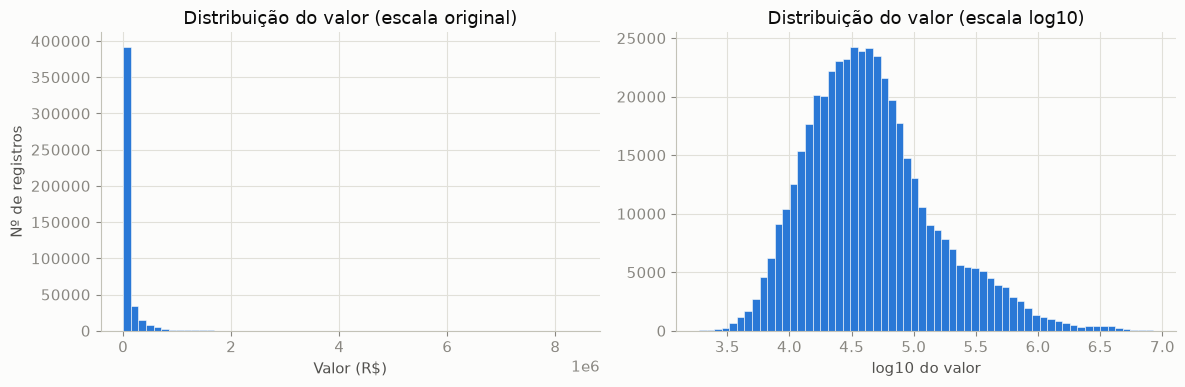

Média:    R$      115.746
Mediana:  R$       39.416
Máximo:   R$    8.407.082
Assimetria (skew): 9.9


In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

eixos[0].hist(df["valor"], bins=60, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.4)
eixos[0].set_title("Distribuição do valor (escala original)")
eixos[0].set_xlabel("Valor (R$)")
eixos[0].set_ylabel("Nº de registros")

eixos[1].hist(np.log10(df["valor"]), bins=60, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.4)
eixos[1].set_title("Distribuição do valor (escala log10)")
eixos[1].set_xlabel("log10 do valor")

plt.tight_layout()
plt.show()

print("Média:    R$ " + f"{df['valor'].mean():>12,.0f}".replace(",", "."))
print("Mediana:  R$ " + f"{df['valor'].median():>12,.0f}".replace(",", "."))
print("Máximo:   R$ " + f"{df['valor'].max():>12,.0f}".replace(",", "."))
print(f"Assimetria (skew): {df['valor'].skew():.1f}")


**Interpretação.** Na escala original (esquerda) a distribuição é **fortemente assimétrica à
direita**: a grande maioria dos veículos vale menos de R$ 100 mil, mas a cauda se estende até
R$ 8,4 milhões (superesportivos e carros de luxo, como o Rolls-Royce Cullinan visto na seção 3.2).
O coeficiente de assimetria impresso acima confirma numericamente o que o gráfico mostra.

Já em **escala logarítmica** (direita) a distribuição fica aproximadamente simétrica, em forma de
sino. Isso tem duas implicações práticas:

1. métricas quadráticas como o RMSE serão **dominadas pelos veículos caros** — algo a considerar na
   avaliação dos modelos;
2. uma **transformação logarítmica do alvo** é uma candidata natural no pré-processamento,
   especialmente para a regressão linear, que assume relação aditiva entre atributos e alvo.


### 3.5 Cobertura temporal dos dados

Por fim, verificamos como os registros se distribuem ao longo dos anos de referência — o
"desbalanceamento" possível em um problema de regressão como este não é de classes (não há classes),
mas de **representatividade das regiões do espaço de entrada**, em particular do tempo.


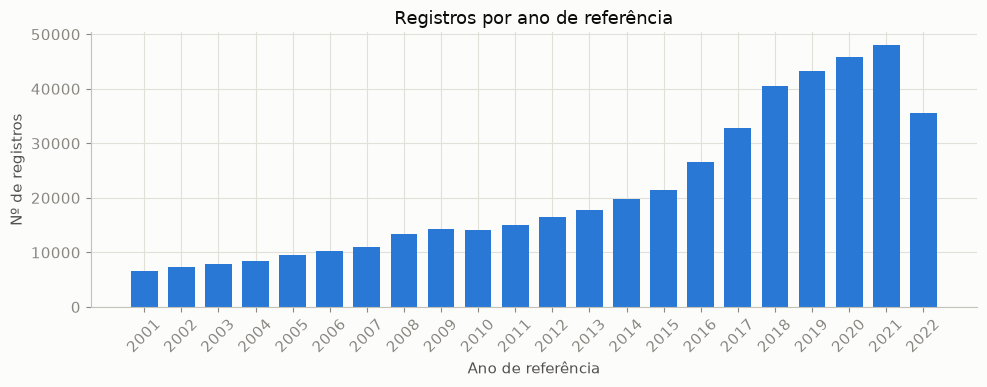

Meses cobertos em 2022: [1, 2, 3, 4, 5, 6, 7, 8]


In [10]:
contagem_ano = df["anoReferencia"].value_counts().sort_index()

fig, eixo = plt.subplots(figsize=(10, 4))
eixo.bar(contagem_ano.index, contagem_ano.values, width=0.72, color=AZUL)
eixo.set_title("Registros por ano de referência")
eixo.set_xlabel("Ano de referência")
eixo.set_ylabel("Nº de registros")
eixo.set_xticks(contagem_ano.index)
eixo.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Meses cobertos em 2022:", sorted(df.loc[df["anoReferencia"] == 2022, "mesReferencia"].unique().tolist()))


**Interpretação.** A cobertura cresce de ~6,7 mil registros em 2001 para ~48 mil em 2021 — reflexo
tanto da ampliação do número de modelos acompanhados pela FIPE quanto da diversificação da frota
brasileira. A queda em 2022 não é real: a coleta do dataset cobre apenas **janeiro a agosto de 2022**,
como mostra a verificação acima.

Implicações: os anos recentes pesam mais no treinamento, e os preços são **nominais** (não corrigidos
pela inflação) — um carro de R$ 30 mil em 2005 não é comparável a um de R$ 30 mil em 2022. A data de
referência, portanto, não é um detalhe: é um atributo preditivo essencial, e esse será um ponto
central da análise exploratória a seguir.

---

**Síntese da compreensão dos dados**

| Achado | Consequência para as próximas etapas |
|---|---|
| 466.020 registros × 8 colunas, sem nulos | Nenhuma imputação necessária |
| `Unnamed: 0` é índice residual | Descartar no pré-processamento |
| 2 pares de duplicatas lógicas (grafias divergentes de `modelo`) | Remover 2 linhas; usar `codigoFipe` como identificador |
| `anoModelo = 2022` codifica **zero km** (102 mil registros) | Criar `zero_km` e idade = 0; registrar ambiguidade 2021–22 como limitação |
| Alvo com forte assimetria à direita | Considerar alvo em log; RMSE dominado por carros caros |
| `modelo` com 5.366 valores distintos | One-hot só para `marca`; outra estratégia para `modelo` |
| Cobertura temporal cresce ao longo dos anos; preços nominais | Data de referência é atributo essencial; analisar erros por período |
